In [ ]:

# 1. Imports

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

# 2. Load dataset

csv_path = "/content/drive/MyDrive/Sikkim/sikkim_ls_onehot.csv"
df = pd.read_csv(csv_path)

# Quick sanity check
print(df.shape)
df.head()


# 3. Drop ID columns

df = df.drop(columns=["fid"])


(1222, 32)


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns




# # OPTION A: Drop rows with any NaN

# df_clean = df.dropna()

# print("Rows after dropping NaNs:", df_clean.shape[0])


# # OPTION B: Impute NaNs

# df_clean = df.copy()

# # Soil is categorical → use special category
# df_clean["Soil_type"] = df_clean["Soil_type"].fillna(-1)

# # Continuous variables → median imputation
# continuous_cols = df_clean.columns.drop(["Label", "Soil_type"])

# for col in continuous_cols:
#     df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# print("Rows after imputation:", df_clean.shape[0])

In [ ]:

# 5. Feature / label split

X = df.drop(columns=["Label"])
y = df["Label"]

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())


X shape: (1222, 30)
y distribution:
 Label
1    612
0    610
Name: count, dtype: int64


In [ ]:
# ===============================
# 3.5 Convert one-hot encoded categorical variables
# ===============================

# Identify one-hot columns
lulc_cols = [c for c in X.columns if c.startswith("lulc_")]
soil_cols = [c for c in X.columns if c.startswith("soil_type_")]
lith_cols = [c for c in X.columns if c.startswith("lithology_")]

def onehot_to_category(df, cols, prefix):
    cat = df[cols].idxmax(axis=1)
    cat = cat.str.replace(prefix, "", regex=False).astype(int)
    df = df.drop(columns=cols)
    df[prefix.rstrip("_")] = cat
    return df

# Apply conversion
X_cat = X.copy()
X_cat = onehot_to_category(X_cat, lulc_cols, "lulc_")
X_cat = onehot_to_category(X_cat, soil_cols, "soil_type_")
X_cat = onehot_to_category(X_cat, lith_cols, "lithology_")

print("Categorical variables converted:")
print(X_cat[["lulc", "soil_type", "lithology"]].head())


Categorical variables converted:
   lulc  soil_type  lithology
0     3          3          1
1     3          3          1
2     3          3          1
3     5          3          1
4     3          3          1


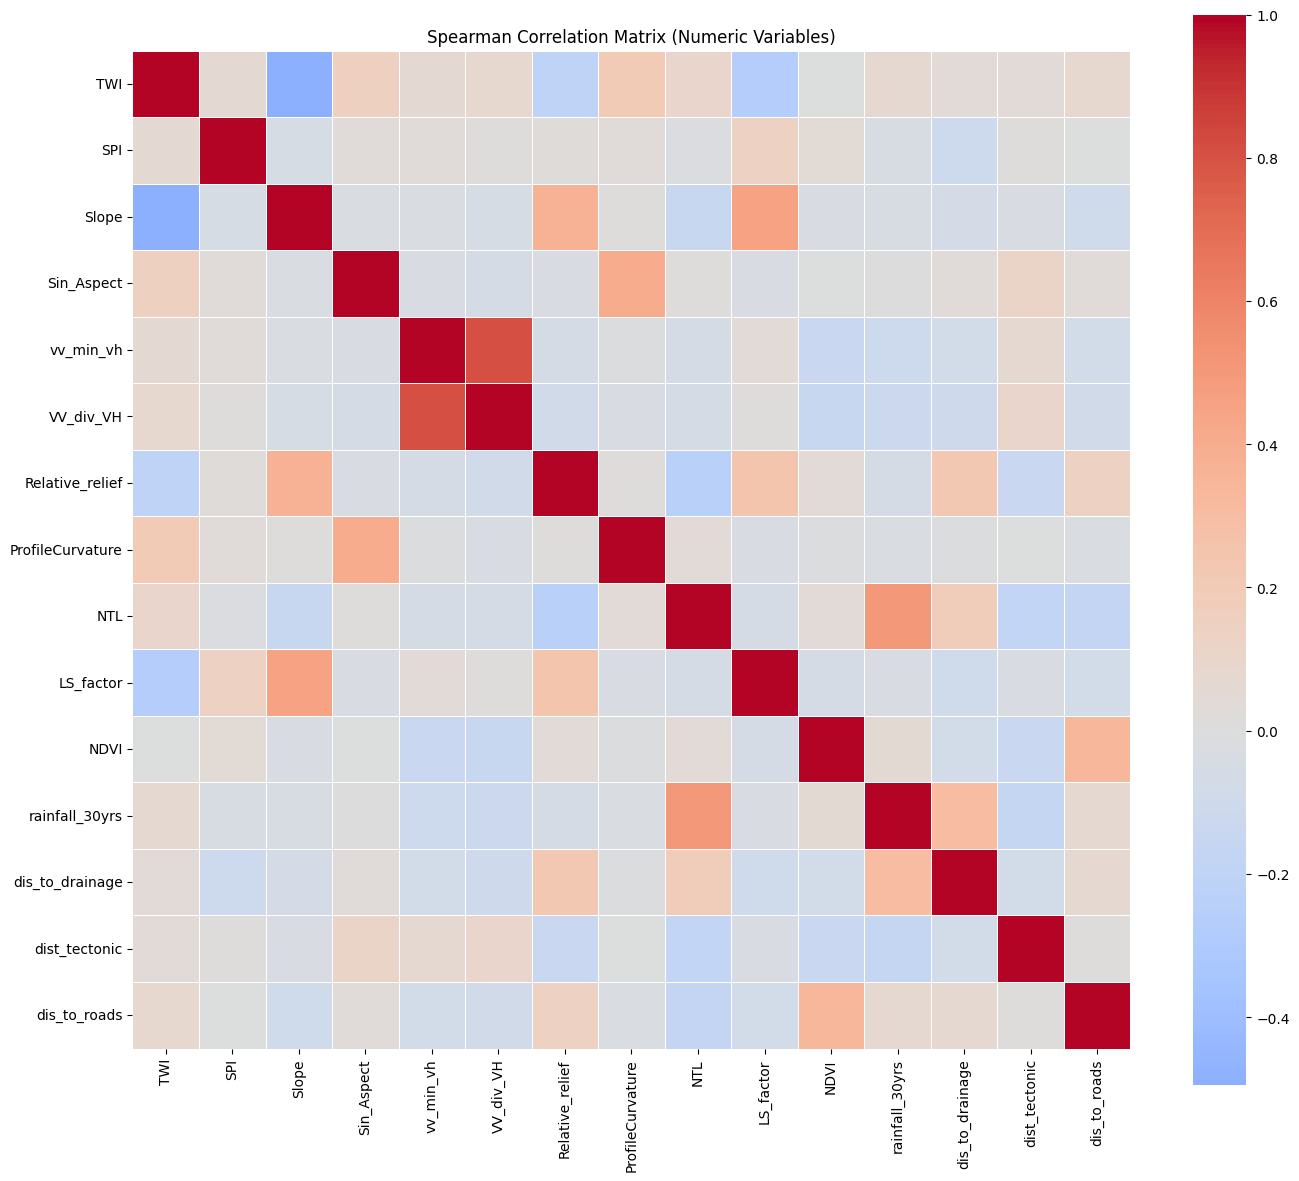

,Variable,VIF
4,vv_min_vh,159.945894
5,VV_div_VH,159.672322
9,LS_factor,53.364687
0,TWI,50.906775
11,rainfall_30yrs,37.191940
2,Slope,16.075615
10,NDVI,13.963092
6,Relative_relief,13.502953
12,dis_to_drainage,3.457635
8,NTL,1.840654


Dropping vv_min_vh (VIF=159.95)
Dropping LS_factor (VIF=52.74)
Dropping TWI (VIF=48.39)
Dropping rainfall_30yrs (VIF=31.38)
Dropping VV_div_VH (VIF=17.08)
Dropping Relative_relief (VIF=11.76)
Final features:
['SPI', 'Slope', 'Sin_Aspect', 'ProfileCurvature', 'NTL', 'NDVI', 'dis_to_drainage', 'dist_tectonic', 'dis_to_roads', 'lulc', 'soil_type', 'lithology']


In [ ]:
# ===============================
# 4. Correlation + VIF (numeric variables ONLY)
# ===============================

import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

categorical_vars = ["lulc", "soil_type", "lithology"]

# Numeric-only dataset for correlation & VIF
X_num = X_cat.drop(columns=categorical_vars)

# -------------------------------
# Spearman correlation (numeric)
# -------------------------------
corr = X_num.corr(method="spearman")

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Spearman Correlation Matrix (Numeric Variables)")
plt.tight_layout()
plt.show()


# -------------------------------
# Prepare for VIF
# -------------------------------
X_vif = X_num.replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.dropna()

zero_var_cols = X_vif.columns[X_vif.nunique() <= 1]
X_vif = X_vif.drop(columns=zero_var_cols)

# -------------------------------
# VIF computation
# -------------------------------
def compute_vif(df):
    return pd.DataFrame({
        "Variable": df.columns,
        "VIF": [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    }).sort_values("VIF", ascending=False)

vif_df = compute_vif(X_vif)
display(vif_df)


# -------------------------------
# Iterative VIF filtering
# -------------------------------
def vif_feature_selection(df, threshold=10.0):
    df = df.copy()
    while True:
        vif = compute_vif(df)
        if vif["VIF"].max() > threshold:
            drop_var = vif.iloc[0]["Variable"]
            print(f"Dropping {drop_var} (VIF={vif.iloc[0]['VIF']:.2f})")
            df = df.drop(columns=[drop_var])
        else:
            break
    return df

X_vif_selected = vif_feature_selection(X_vif)

# -------------------------------
# FINAL feature matrix
# -------------------------------
X_final = pd.concat(
    [X_vif_selected, X_cat[categorical_vars]],
    axis=1
)

print("Final features:")
print(X_final.columns.tolist())


In [ ]:

# 6. Train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
# ===============================
# k-Fold Cross Validation (5 & 10 fold)
# ===============================

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score
import numpy as np

# Base XGBoost model for CV (NOT GridSearch model)
xgb_cv_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

def run_xgb_cv(model, X, y, n_splits=5, threshold=0.5, random_state=42):
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    f1_scores = []
    auc_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_val)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)

        f1_scores.append(f1)
        auc_scores.append(auc)

        print(f"Fold {fold} | F1: {f1:.4f} | AUC: {auc:.4f}")

    print("\nSummary")
    print(f"Mean F1 : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
    print(f"Mean AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

    return f1_scores, auc_scores


# ---------- Run 5-Fold CV ----------
print("===== 5-Fold Cross Validation =====")
f1_5, auc_5 = run_xgb_cv(
    model=xgb_cv_model,
    X=X_final,
    y=y,
    n_splits=5,
    threshold=0.5
)

# ---------- Run 10-Fold CV ----------
print("\n===== 10-Fold Cross Validation =====")
f1_10, auc_10 = run_xgb_cv(
    model=xgb_cv_model,
    X=X_final,
    y=y,
    n_splits=10,
    threshold=0.5
)


===== 5-Fold Cross Validation =====
Fold 1 | F1: 0.8279 | AUC: 0.9076
Fold 2 | F1: 0.8034 | AUC: 0.8836
Fold 3 | F1: 0.7679 | AUC: 0.8382
Fold 4 | F1: 0.8000 | AUC: 0.8862
Fold 5 | F1: 0.7866 | AUC: 0.8558

Summary
Mean F1 : 0.7972 ± 0.0198
Mean AUC: 0.8743 ± 0.0244

===== 10-Fold Cross Validation =====
Fold 1 | F1: 0.8462 | AUC: 0.9196
Fold 2 | F1: 0.7895 | AUC: 0.9162
Fold 3 | F1: 0.8500 | AUC: 0.9076
Fold 4 | F1: 0.7407 | AUC: 0.8603
Fold 5 | F1: 0.7667 | AUC: 0.8363
Fold 6 | F1: 0.7667 | AUC: 0.8479
Fold 7 | F1: 0.8197 | AUC: 0.8839
Fold 8 | F1: 0.8500 | AUC: 0.9105
Fold 9 | F1: 0.8136 | AUC: 0.8863
Fold 10 | F1: 0.7937 | AUC: 0.8167

Summary
Mean F1 : 0.8037 ± 0.0367
Mean AUC: 0.8785 ± 0.0345


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.6, 0.8],
    "min_child_weight": [1, 5]
}

grid = GridSearchCV(
    xgb_base,
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

xgb = grid.best_estimator_

print("Best XGB parameters:")
print(grid.best_params_)
print("Best CV F1:", grid.best_score_)


Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best XGB parameters:
{'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}
Best CV F1: 0.8085560686686424


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85       122
           1       0.84      0.87      0.85       123

    accuracy                           0.85       245
   macro avg       0.85      0.85      0.85       245
weighted avg       0.85      0.85      0.85       245

ROC AUC: 0.911235505797681
F1 Score: 0.852589641434263


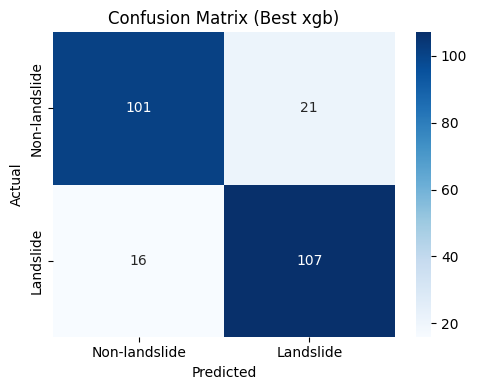

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
)

# Predictions
y_prob = xgb.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.53).astype(int)

# Core metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("F1 Score:", f1_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-landslide", "Landslide"],
    yticklabels=["Non-landslide", "Landslide"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Best xgb)")
plt.tight_layout()
plt.show()


In [ ]:
# import numpy as np

# thresholds = np.linspace(0.3, 0.7, 41)
# f1_scores = []

# for t in thresholds:
#     y_t = (y_prob >= t).astype(int)
#     f1_scores.append(f1_score(y_test, y_t))

# best_t = thresholds[np.argmax(f1_scores)]
# print("Best threshold:", best_t)
# print("Best F1:", max(f1_scores))


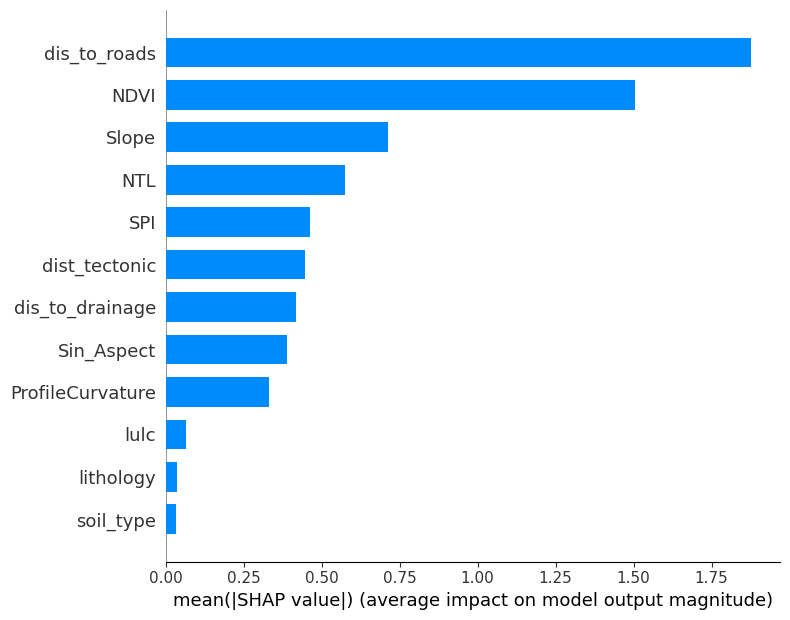

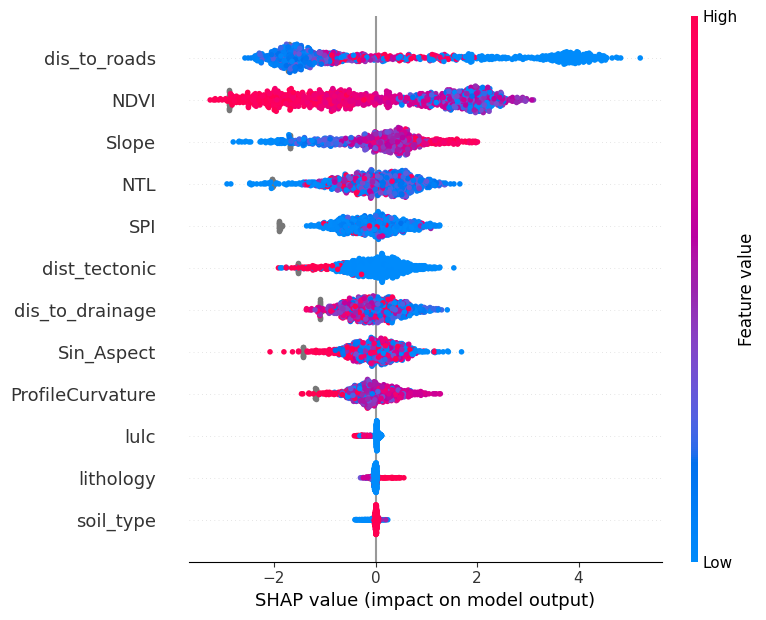

In [ ]:
import shap
import numpy as np

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_train)

# -------------------------------
# Handle SHAP output safely
# -------------------------------

# XGBoost binary classifier → 2D array
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 2:
    shap_vals = shap_values

# RandomForest (older behaviour) → list
elif isinstance(shap_values, list):
    shap_vals = shap_values[1]

# RandomForest (newer behaviour) → 3D array
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_vals = shap_values[:, :, 1]

else:
    raise ValueError("Unexpected SHAP output format")

# -------------------------------
# 1. Global feature importance
# -------------------------------
shap.summary_plot(
    shap_vals,
    X_train,
    plot_type="bar",
    max_display=20
)

# -------------------------------
# 2. Global impact + direction
# -------------------------------
shap.summary_plot(
    shap_vals,
    X_train,
    max_display=20
)


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.25, 0.6, 71)
f1_scores = []

for t in thresholds:
    y_t = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_t))

best_t = thresholds[np.argmax(f1_scores)]
print("Best threshold:", best_t)
print("Best F1:", max(f1_scores))


Best threshold: 0.53
Best F1: 0.852589641434263


In [ ]:
import joblib
import os

save_dir = "/content/drive/MyDrive/LSM_models"
os.makedirs(save_dir, exist_ok=True)

bundle = {
    "model": xgb,
    "feature_order": X_final.columns.tolist(),
    "threshold": 0.53,   # your optimized threshold
}

joblib.dump(bundle, os.path.join(save_dir, "xgb_cor2.pkl"))

print("Model + metadata saved successfully.")


Model + metadata saved successfully.
